In [1]:
import Pkg; Pkg.add("FFTW")
import Gmsh: gmsh
using Gridap, GridapGmsh
using Random, LinearAlgebra, FFTW

   Resolving package versions...
  No Changes to `~/.julia/environments/v1.11/Project.toml`
  No Changes to `~/.julia/environments/v1.11/Manifest.toml`


In [17]:
function create_square_model(h)
    gmsh.initialize()
    gmsh.model.add("unit_square")
    gmsh.model.geo.addPoint(0,0,0,1,1) # last argument is optional identifier, unique per dimension
    gmsh.model.geo.addPoint(1,0,0,1,2)
    gmsh.model.geo.addPoint(1,1,0,1,3)
    gmsh.model.geo.addPoint(0,1,0,1,4)
    gmsh.model.geo.addLine(1,2,1)
    gmsh.model.geo.addLine(2,3,2) # line 2 goes from point 2 to point 3
    gmsh.model.geo.addLine(3,4,3)
    gmsh.model.geo.addLine(4,1,4)
        
    gmsh.model.geo.addCurveLoop([1,2,3,4],1)
        
    gmsh.model.geo.addPlaneSurface([1],1)

    N = Int(round(1/h))  # number of elements per edge

    gmsh.model.geo.mesh.setTransfiniteCurve(1, N+1)
    gmsh.model.geo.mesh.setTransfiniteCurve(2, N+1)
    gmsh.model.geo.mesh.setTransfiniteCurve(3, N+1)
    gmsh.model.geo.mesh.setTransfiniteCurve(4, N+1)

    #triangulation
    gmsh.model.geo.mesh.setTransfiniteSurface(1)

    gmsh.model.geo.synchronize()

    # Define physical groups without the string argument
    edges_tag = gmsh.model.addPhysicalGroup(1, [1, 2, 3, 4])   # edges
    corners_tag = gmsh.model.addPhysicalGroup(0, [1, 2, 3, 4]) # corners
    domain_tag = gmsh.model.addPhysicalGroup(2, [1])           # surface
    
    # Set names for the physical groups
    gmsh.model.setPhysicalName(1, edges_tag, "boundary")
    gmsh.model.setPhysicalName(0, corners_tag, "boundary")
    gmsh.model.setPhysicalName(2, domain_tag, "domain")
    gmsh.model.mesh.generate(2)

    model = GmshDiscreteModel(gmsh);
    gmsh.finalize();
    return model
end


create_square_model (generic function with 1 method)

In [27]:
function rho(r, v, p)
    return v^2 * exp(-p*r)
end

function matern_rho(d, σ, v, p) 
    return σ^2 * (2.0^(1-v) / gamma(v)) * ((sqrt(2*v) * d / p)^v) * besselk(v, (sqrt(2*v) * d / p))
end

function algorithm1(m0, v, p; tol=1e-12)
    m  = m0  #step 1
    h0 = 1/m0

    while true
        n = 2m

        #step 2: modified version because I'm not sure how to do it the column way
        C = zeros(n,n) 
        for i in 1:n, j in 1:n 
            ii = min(i-1, n-(i-1)) 
            jj = min(j-1, n-(j-1)) 
            dx = ii*h0
            dy = jj*h0 
            dist = sqrt(dx^2 + dy^2) 
            C[i,j] = rho(dist,v,p) 
            #C[i,j] = matern_rho(dist,v,p) 
        end

        #step 3: eigenvalues via fft
        λ  = real.(fft(C))

        #step 4: check
        if minimum(λ) >= 0
            λ .= max.(λ, 0.0)
            return m, λ
        else
            m += 1
        end
    end
end

function algorithm2(m0, m, λ; rng=Random.default_rng()) 
    n = 2m #step 1: sample y 
    ξ = (randn(rng, n, n) .+ 1im * randn(rng, n, n)) ./ sqrt(2) 
    #step 2: apply sqrt(Λ) and inverse FFT 
    Y = ifft(sqrt.(complex.(λ)) .* ξ) 
    #step 3: restrict to (m0+1)x(m0+1) 
    Z = real.(Y[1:(m0+1), 1:(m0+1)]) 
    return Z 
end



algorithm2 (generic function with 1 method)

In [28]:
function sample_random_field(m0, v, p; rng=Random.default_rng(), tol=1e-12)
    m, λ = algorithm1(m0, v, p; tol=tol)
    Z    = algorithm2(m0, m, λ; rng=rng)
    return Z, m
end

function grid_to_function(Z,m0)

    h = 1/m0

    function f(x)

        #convert coordinate to grid index
        i = clamp(Int(round(x[1]/h)),1,m0+1)
        j = clamp(Int(round(x[2]/h)),1,m0+1)

        return Z[i,j]

    end

    return f

end

grid_to_function (generic function with 1 method)

In [29]:
h = 1/64
v = 10
p = 25

model = create_square_model(h)

reffe = ReferenceFE(lagrangian,Float64,1)

V = TestFESpace(model,reffe,conformity=:H1)
U = TrialFESpace(V)

m0 = Int(round(1/h))

Z, m = sample_random_field(m0, v, p; rng=MersenneTwister(1))

f = grid_to_function(Z,m0)

zh = interpolate_everywhere(f,U)

Ω = Triangulation(model)

writevtk(Ω,"random_field",cellfields=["Z"=>zh])

Info    : Meshing 1D...
Info    : [  0%] Meshing curve 1 (Line)
Info    : [ 30%] Meshing curve 2 (Line)
Info    : [ 60%] Meshing curve 3 (Line)
Info    : [ 80%] Meshing curve 4 (Line)
Info    : Done meshing 1D (Wall 0.0346216s, CPU 0.035342s)
Info    : Meshing 2D...
Info    : Meshing surface 1 (Transfinite)
Info    : Done meshing 2D (Wall 0.0722266s, CPU 0.072205s)
Info    : 4225 nodes 8452 elements


(["random_field.vtu"],)

In [30]:
function q_true(m0, v, p, x_idx, y_idx)
    ix, iy = x_idx
    jx, jy = y_idx
    x = (ix/m0, iy/m0)
    y = (jx/m0, jy/m0)
    return v^2 * exp(-p * sqrt((x[1]-y[1])^2 + (x[2]-y[2])^2))
end

function empirical_covariance(m0, v, p; N=5000, x_idx=(10,20), y_idx=(40,5), seed=1)
    rng = MersenneTwister(seed)

    m, λ = algorithm1(m0, v, p)

    ix, iy = x_idx
    jx, jy = y_idx

    sx = 0.0
    sy = 0.0
    sxy = 0.0

    for n in 1:N
        Z = algorithm2(m0, m, λ; rng=rng)
        X = Z[ix+1, iy+1]
        Y = Z[jx+1, jy+1]

        sx += X
        sy += Y
        sxy += X*Y
    end

    mx = sx/N
    my = sy/N
    cov = sxy/N - mx*my
    return cov, m
end

empirical_covariance (generic function with 1 method)

In [33]:
m0 = 128
v  = 10.0
p  = 25.0

running, q, x, y, m = check_covariance_convergence_fast(m0, v, p; N=20000, x_idx=(10,20), y_idx=(40,5))
println("Embedding m = $m")
println("x = $x, y = $y")
println("true q(x,y) = $q")
println("empirical qhat_N (last) = $(running[end])")

Embedding m = 128
x = (0.078125, 0.15625), y = (0.3125, 0.0390625)
true q(x,y) = 0.14287141960076857
empirical qhat_N (last) = 6.766726928551417e-6


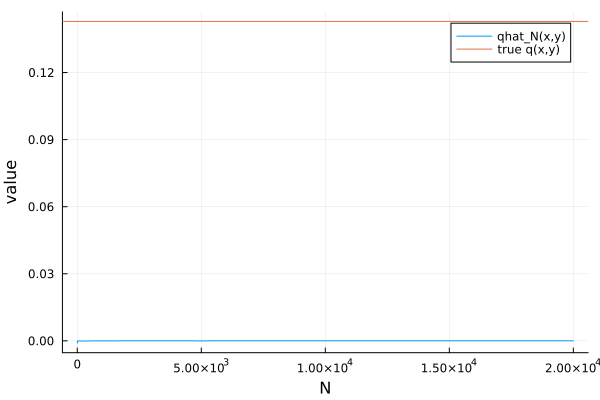

In [34]:
using Plots
plot(running, label="qhat_N(x,y)")
hline!([q], label="true q(x,y)")
xlabel!("N")
ylabel!("value")